# 16 · Stochastic differential equations

An SDE dX = a(X) dt + b(X) dW adds Brownian noise to an ODE. Because Brownian paths are rough, the calculus is
new (Itô's lemma, the Itô-Stratonovich distinction) and so are the numerics: the Euler-Maruyama scheme
converges with strong order ½ (pathwise) and weak order 1 (in distribution), Milstein's correction restores
strong order 1, and multilevel Monte Carlo exploits both to cut the cost of expectations by orders of
magnitude.

**What you will learn**
- solve SDEs by Euler-Maruyama, Milstein and Heun
- measure strong and weak orders of convergence correctly
- distinguish Ito and Stratonovich interpretations
- use multilevel Monte Carlo for expectations

**Before you start:** notebook 15; ordinary differential equations  ·  **Time:** about 90 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import sde, brownian as bm, montecarlo as mc
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Euler-Maruyama and an exact solution

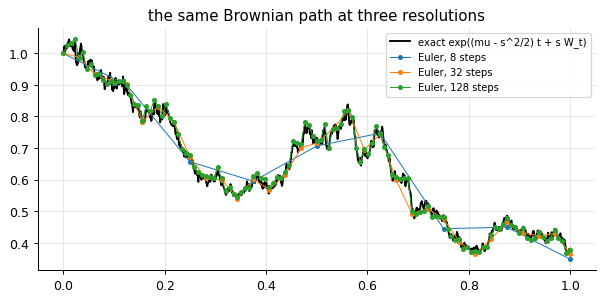

In [2]:
mu, sig = 0.1, 0.5
a = lambda t, x: mu * x
b = lambda t, x: sig * x
fine = sde.euler_maruyama(a, b, 1.0, 1.0, 1024, 1, R(1))
WT = np.cumsum(fine["dW"][0, :, 0])
exact = np.exp((mu - sig**2 / 2) * fine["t"][1:] + sig * WT)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(fine["t"][1:], exact, "k", lw=1.5, label="exact exp((mu - s^2/2) t + s W_t)")
for n in (8, 32, 128):
    dWc = fine["dW"].reshape(1, n, 1024 // n, 1).sum(axis=2)
    e = sde.euler_maruyama(a, b, 1.0, 1.0, n, 1, R(0), dW=dWc)
    ax.plot(e["t"], e["X"][0], "o-", ms=3, lw=0.8, label=f"Euler, {n} steps")
ax.legend(fontsize=8); ax.set_title("the same Brownian path at three resolutions"); plt.show()

Itô's lemma solves geometric Brownian motion exactly: X_t = exp((μ − σ²/2)t + σW_t). The −σ²/2 is the Itô
correction - d(log X) picks up −½σ² dt from (dW)² = dt. To compare a scheme with the exact solution *pathwise*
the scheme must use the same Brownian path: the coarse increments are sums of the fine ones.

## Strong and weak convergence

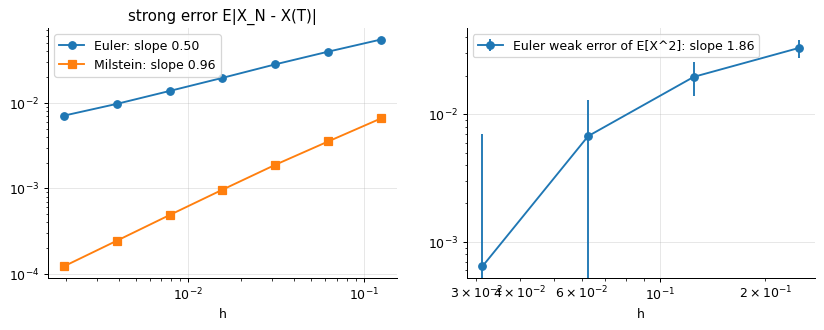

In [3]:
steps = [8, 16, 32, 64, 128, 256, 512]
ex = lambda t, W: np.exp((mu - sig**2 / 2) * t + sig * W)
se = sde.strong_order(a, b, ex, 1.0, 1.0, steps, 4000, R(2))
sm = sde.strong_order(a, b, ex, 1.0, 1.0, steps, 4000, R(2), "milstein", lambda t, x: sig + 0 * x)
wo = sde.weak_order(a, b, 1.0, 1.0, [4, 8, 16, 32], 400_000, R(3), lambda x: x**2, np.exp((2 * mu + sig**2) * 1.0))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].loglog(se["h"], se["error"], "o-", label=f"Euler: slope {se['order']:.2f}"); ax[0].loglog(sm["h"], sm["error"], "s-", label=f"Milstein: slope {sm['order']:.2f}")
ax[0].set_xlabel("h"); ax[0].set_title("strong error E|X_N - X(T)|"); ax[0].legend()
ax[1].errorbar(wo["h"], wo["error"], 2 * wo["std_error"], fmt="o-", label=f"Euler weak error of E[X^2]: slope {wo['order']:.2f}"); ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].legend(); ax[1].set_xlabel("h"); plt.show()

Strong error measures how close individual paths are; weak error how close expectations are. Euler-Maruyama
has strong order ½ (it ignores the second-order term ½bb′((ΔW)² − Δt), of size Δt per step but random), and
weak order 1 (that term has mean zero). Milstein adds it and reaches strong order 1. For expectations - option
prices, mean queue lengths, failure probabilities - weak order is what matters, and the Monte Carlo error must
be well below the bias to see it, hence 400 000 paths.

## Itô or Stratonovich?

In [4]:
n, paths = 400, 4000
h = sde.heun_stratonovich(lambda t, x: 0 * x, lambda t, x: 0.4 * x, 1.0, 1.0, n, paths, R(4))
WT = h["dW"].sum(axis=1)[:, 0]
e = sde.euler_maruyama(lambda t, x: 0 * x, lambda t, x: 0.4 * x, 1.0, 1.0, n, paths, R(4), dW=h["dW"])
print(f"dX = 0.4 X dW integrated by Heun: mean |X - exp(0.4 W)| = {np.mean(np.abs(h['X'][:, -1] - np.exp(0.4 * WT))):.1e}  (Stratonovich solution)")
print(f"                         by Euler: mean |X - exp(0.4 W - 0.08)| = {np.mean(np.abs(e['X'][:, -1] - np.exp(0.4 * WT - 0.08))):.1e}  (Ito solution)")
print(f"E[X_1]: Heun {h['X'][:, -1].mean():.4f} (e^0.08 = {np.exp(0.08):.4f}), Euler {e['X'][:, -1].mean():.4f} (1)")

dX = 0.4 X dW integrated by Heun: mean |X - exp(0.4 W)| = 8.9e-05  (Stratonovich solution)
                         by Euler: mean |X - exp(0.4 W - 0.08)| = 4.5e-03  (Ito solution)
E[X_1]: Heun 1.0851 (e^0.08 = 1.0833), Euler 1.0018 (1)


The same equation means two different things. Read as Itô (integrand evaluated at the left end of each step,
as Euler does), the solution exp(0.4W − 0.08) is a martingale; read as Stratonovich (midpoint, as Heun's
trapezoidal rule does), it is exp(0.4W) and grows on average. Stratonovich obeys the ordinary chain rule and
arises as the limit of smooth noise (physics, engineering); Itô is non-anticipating and natural in finance and
biology. The drift correction ½bb′ converts one into the other.

## Mean reversion: Ornstein-Uhlenbeck and CIR

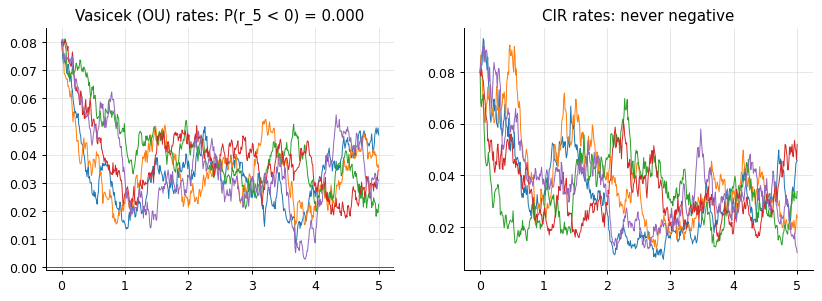

OU exact sampling at t = 5: mean 0.0302 (theory 0.0300), sd 0.0098 (theory 0.0100)
CIR at t = 5: mean 0.0302 (theory 0.0300); Feller condition 2 kappa theta >= sigma^2: 0.120 vs 0.0225


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ou = bm.ou_exact(0.08, 2.0, 0.03, 0.02, 5.0, 500, 2000, R(5))
ax[0].plot(np.linspace(0, 5, 501), ou[:5].T, lw=0.8); ax[0].axhline(0, color="k", lw=0.5); ax[0].set_title(f"Vasicek (OU) rates: P(r_5 < 0) = {np.mean(ou[:, -1] < 0):.3f}")
cir = sde.cir_full_truncation(0.08, 2.0, 0.03, 0.15, 5.0, 500, 2000, R(6))
ax[1].plot(np.linspace(0, 5, 501), cir[:5].T, lw=0.8); ax[1].set_title("CIR rates: never negative"); plt.show()
m = bm.ou_moments(0.08, 2.0, 0.03, 0.02, 5.0)
print(f"OU exact sampling at t = 5: mean {ou[:, -1].mean():.4f} (theory {float(m['mean']):.4f}), sd {ou[:, -1].std():.4f} (theory {np.sqrt(float(m['var'])):.4f})")
print(f"CIR at t = 5: mean {cir[:, -1].mean():.4f} (theory {float(sde.cir_mean(0.08, 2.0, 0.03, 5.0)):.4f}); Feller condition 2 kappa theta >= sigma^2: {2 * 2.0 * 0.03:.3f} vs {0.15**2:.4f}")

The OU process is Gaussian and can be sampled exactly on any grid (an AR(1) recursion); as an interest-rate
model (Vasicek) it allows negative rates. CIR replaces the constant noise by σ√X, which vanishes at zero and
keeps the process non-negative - but naive Euler can step below zero and then take a square root of a
negative number; the full-truncation scheme uses X⁺ in the coefficients and is the standard fix.

## Multilevel Monte Carlo

In [6]:
payoff = lambda S: np.maximum(S - 100.0, 0.0)
bs = bm.black_scholes_call(100.0, 100.0, 0.05, 0.2, 1.0)
rows = []
for eps in (0.1, 0.05, 0.02):
    r = sde.mlmc(payoff, 100.0, 0.05, 0.2, 1.0, eps, R(int(1 / eps)), L=6)
    std_cost = 2 * r["variances"][0] / eps**2 * 2**6
    rows.append((eps, r["estimate"], r["estimate"] - bs, r["std_error"], r["cost"], std_cost, std_cost / r["cost"]))
print(pd.DataFrame(rows, columns=["target eps", "MLMC price", "error vs Black-Scholes", "std error", "MLMC cost (steps)", "standard MC cost", "saving"]).to_string(index=False, float_format="%.4g"))
print("samples per level at eps = 0.02:", r["samples"].tolist(), "\nvariance of the level corrections:", np.round(r["variances"], 4).tolist())

 target eps  MLMC price  error vs Black-Scholes  std error  MLMC cost (steps)  standard MC cost  saving
        0.1       10.54                 0.09182     0.0705           1.39e+05         2.068e+06   14.88
       0.05       10.39                 -0.0614    0.03622          5.387e+05         8.203e+06   15.23
       0.02       10.45              -0.0003964    0.01432          3.468e+06         5.149e+07   14.85
samples per level at eps = 0.02: [1635578, 140918, 69139, 39055, 20494, 9919, 4945] 
variance of the level corrections: [160.9136, 2.3713, 1.2554, 0.6783, 0.3472, 0.1824, 0.094]


Giles's idea: write E[P_L] as E[P_0] + Σ E[P_l − P_{l−1}] and estimate each term separately, with coarse and
fine paths driven by the same Brownian increments. The corrections have tiny variance (it decays like the
step size), so few expensive fine-level samples are needed; most samples are cheap coarse ones. The cost
falls from O(ε⁻³) to O(ε⁻²(log ε)²) - a factor of about fifteen here with the number of levels fixed at six;
when the finest level is chosen to match ε (as it should be, to keep the bias below ε), the saving grows as ε
shrinks.

## Inside the algorithm: one Milstein step

In [7]:
x0, dt_, dW = 1.0, 0.01, 0.07
em = x0 + mu * x0 * dt_ + sig * x0 * dW
mil = em + 0.5 * (sig * x0) * sig * (dW**2 - dt_)
ex = x0 * np.exp((mu - sig**2 / 2) * dt_ + sig * dW)
print(f"exact {ex:.8f}, Euler {em:.8f} (error {abs(em - ex):.1e}), Milstein {mil:.8f} (error {abs(mil - ex):.1e})")

exact 1.03536084, Euler 1.03600000 (error 6.4e-04), Milstein 1.03536250 (error 1.7e-06)


## Exercises
1. For the Langevin equation dX = -X dt + sqrt(2) dW, compare the stationary variance of Euler-Maruyama with step h against the exact value 1. Derive the Euler value 1/(1 - h/2) and check it.
2. Simulate the CIR process with 2 kappa theta < sigma^2 by plain Euler (with max(x, 0) inside the square root only) and by full truncation; compare their means at T = 1 with the exact value for h = 0.1, 0.01.
3. **Implement it yourself:** write the MLMC level estimator for the GBM call (coupled coarse and fine Euler paths) and verify that Var(P_l - P_{l-1}) halves from one level to the next.